# Shadow Dataset - Exploratory Data Analysis
### BrabantHack_26 | DEMCON Track: Shadows — Detection Before Appearance

**Before running:** Update `DATA_DIR` in the cell below.

**Dependencies:** `uv add pillow matplotlib numpy seaborn scipy`


In [1]:
import json
import os
import sys
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import seaborn as sns
from scipy import stats

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.facecolor"] = "white"

DATA_DIR = Path("./train_data")


## 1. Inspect Folder Structure

In [2]:
for root, dirs, files in os.walk(DATA_DIR):
    level = root.replace(str(DATA_DIR), "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for f in sorted(files)[:5]:
            print(f"{indent}  {f}")
        if len(files) > 5:
            print(f"{indent}  ... ({len(files)} files total)")


train_data/
  Thumbs.db
  image_0.json
  image_0.png
  image_10.json
  image_10.png
  ... (3385 files total)


## 2. Load and Parse Dataset

In [3]:
def find_files(data_dir: Path) -> tuple[list[Path], list[Path]]:
    png_files = sorted(data_dir.rglob("*.png"))
    json_files = sorted(data_dir.rglob("*.json"))
    return png_files, json_files


def open_img(path: str, size: tuple = None) -> np.ndarray:
    img = Image.open(path).convert("RGB")
    if size is not None:
        img = img.resize(size)
    return np.array(img) / 255.0


def load_dataset(data_dir: Path) -> list[dict]:
    png_files, json_files = find_files(data_dir)
    if not json_files:
        raise FileNotFoundError(f"No JSON files found under {data_dir}")

    png_lookup = {p.stem: p for p in png_files}

    samples = []
    skipped = 0
    for jf in json_files:
        with open(jf) as f:
            annotation = json.load(f)

        fname = annotation["file_name"]
        if fname not in png_lookup:
            skipped += 1
            continue

        img_path = png_lookup[fname]
        tl = annotation["bbox"]["top_left"]
        br = annotation["bbox"]["bottom_right"]

        sample = {
            "file_name": fname,
            "img_path": str(img_path),
            "walking_into_frame": annotation["walking_into_frame_bool"],
            "x_min": tl[0],
            "y_min": tl[1],
            "x_max": br[0],
            "y_max": br[1],
            "bbox_width": br[0] - tl[0],
            "bbox_height": br[1] - tl[1],
            "bbox_center_x": (tl[0] + br[0]) / 2,
            "bbox_center_y": (tl[1] + br[1]) / 2,
            "bbox_area": (br[0] - tl[0]) * (br[1] - tl[1]),
            "aspect_ratio": (br[0] - tl[0]) / (br[1] - tl[1]) if (br[1] - tl[1]) != 0 else 0,
        }

        if tl[0] < 0:
            sample["person_side"] = "left"
        elif br[0] > 720:
            sample["person_side"] = "right"
        else:
            sample["person_side"] = "in_frame"

        if sample["person_side"] == "left":
            sample["distance_from_edge"] = abs(tl[0])
        elif sample["person_side"] == "right":
            sample["distance_from_edge"] = br[0] - 720
        else:
            sample["distance_from_edge"] = 0.0

        samples.append(sample)

    if skipped > 0:
        print(f"Warning: {skipped} JSON files had no matching image.")
    return samples


samples = load_dataset(DATA_DIR)
print(f"Loaded {len(samples)} samples.")

img = Image.open(samples[0]["img_path"]).convert("RGB")
IMG_W, IMG_H = img.size
print(f"Image dimensions: {IMG_W}x{IMG_H} ({img.mode})")


Loaded 1692 samples.
Image dimensions: 720x480 (RGB)


## 3. Summary Statistics

In [4]:
walk_counts = Counter(s["walking_into_frame"] for s in samples)
side_counts = Counter(s["person_side"] for s in samples)

print(f"Total samples: {len(samples)}")
print(f"\nWalking toward frame: {walk_counts.get(1, 0)} ({walk_counts.get(1, 0)/len(samples)*100:.1f}%)")
print(f"Walking away from frame: {walk_counts.get(0, 0)} ({walk_counts.get(0, 0)/len(samples)*100:.1f}%)")
print(f"\nPerson side distribution:")
for side, count in side_counts.items():
    print(f"  {side}: {count} ({count/len(samples)*100:.1f}%)")

for key, label in [
    ("bbox_width", "Bbox Width"),
    ("bbox_height", "Bbox Height"),
    ("bbox_area", "Bbox Area"),
    ("bbox_center_x", "Bbox Center X"),
    ("bbox_center_y", "Bbox Center Y"),
    ("distance_from_edge", "Distance from Edge"),
    ("aspect_ratio", "Aspect Ratio (W/H)"),
]:
    vals = [s[key] for s in samples]
    print(f"\n{label}:")
    print(f"  mean={np.mean(vals):.2f}  std={np.std(vals):.2f}  min={np.min(vals):.2f}  max={np.max(vals):.2f}")
    print(f"  median={np.median(vals):.2f}  Q1={np.percentile(vals, 25):.2f}  Q3={np.percentile(vals, 75):.2f}")

print(f"\nX coordinate ranges:")
print(f"  x_min: [{min(s['x_min'] for s in samples):.1f}, {max(s['x_min'] for s in samples):.1f}]")
print(f"  x_max: [{min(s['x_max'] for s in samples):.1f}, {max(s['x_max'] for s in samples):.1f}]")
print(f"\nY coordinate ranges:")
print(f"  y_min: [{min(s['y_min'] for s in samples):.1f}, {max(s['y_min'] for s in samples):.1f}]")
print(f"  y_max: [{min(s['y_max'] for s in samples):.1f}, {max(s['y_max'] for s in samples):.1f}]")


Total samples: 1692

Walking toward frame: 818 (48.3%)
Walking away from frame: 874 (51.7%)

Person side distribution:
  left: 852 (50.4%)
  right: 840 (49.6%)

Bbox Width:
  mean=80.85  std=29.86  min=26.82  max=157.17
  median=78.57  Q1=57.21  Q3=102.97

Bbox Height:
  mean=172.90  std=34.67  min=116.50  max=246.90
  median=169.59  Q1=142.76  Q3=202.41

Bbox Area:
  mean=14546.08  std=7429.75  min=3235.95  max=37879.38
  median=12832.85  Q1=9022.75  Q3=19109.77

Bbox Center X:
  mean=343.94  std=529.16  min=-289.40  max=973.19
  median=-117.04  Q1=-175.47  Q3=871.59

Bbox Center Y:
  mean=309.33  std=14.27  min=286.03  max=342.97
  median=307.96  Q1=296.98  Q3=321.00

Distance from Edge:
  mean=208.58  std=45.16  min=115.03  max=359.08
  median=202.53  Q1=174.26  Q3=239.09

Aspect Ratio (W/H):
  mean=0.47  std=0.14  min=0.21  max=0.66
  median=0.49  Q1=0.34  Q3=0.60

X coordinate ranges:
  x_min: [-359.1, 932.9]
  x_max: [-252.9, 1038.8]

Y coordinate ranges:
  y_min: [211.9, 230.3]


## 4. Image Channel Statistics

In [5]:
rng = np.random.default_rng(42)
n_sample = min(50, len(samples))
indices = rng.choice(len(samples), size=n_sample, replace=False)

means, stds = [], []
for idx in indices:
    img = open_img(samples[idx]["img_path"])
    means.append(img.mean(axis=(0, 1)))
    stds.append(img.std(axis=(0, 1)))

channel_means = np.mean(means, axis=0)
channel_stds = np.mean(stds, axis=0)
print(f"Channel means (R, G, B): {channel_means}")
print(f"Channel stds  (R, G, B): {channel_stds}")


Channel means (R, G, B): [0.42181778 0.41278549 0.39355746]
Channel stds  (R, G, B): [0.16677971 0.17377767 0.23348195]


## 5. Dataset Overview

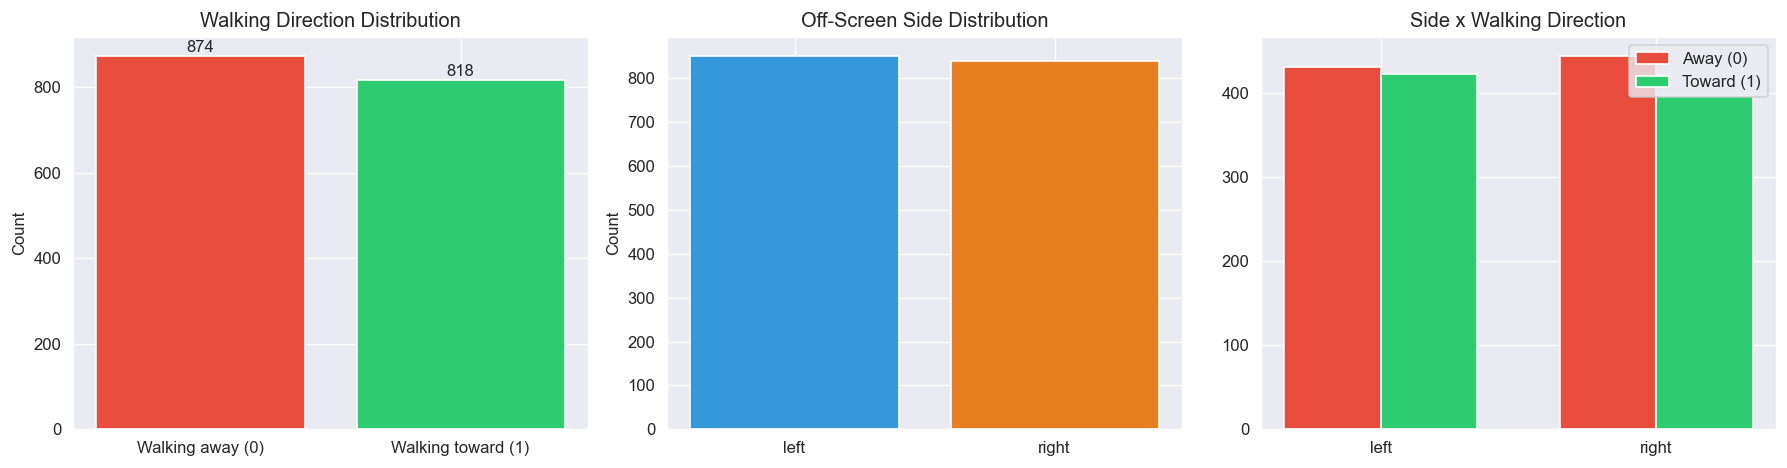

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

walk_counts = Counter(s["walking_into_frame"] for s in samples)
labels = ["Walking away (0)", "Walking toward (1)"]
values = [walk_counts.get(0, 0), walk_counts.get(1, 0)]
axes[0].bar(labels, values, color=["#e74c3c", "#2ecc71"])
axes[0].set_title("Walking Direction Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(values):
    axes[0].text(i, v + max(values) * 0.01, str(v), ha="center", fontsize=10)

side_counts = Counter(s["person_side"] for s in samples)
axes[1].bar(side_counts.keys(), side_counts.values(), color=["#3498db", "#e67e22", "#9b59b6"])
axes[1].set_title("Off-Screen Side Distribution")
axes[1].set_ylabel("Count")

cross = {}
for s in samples:
    key = (s["person_side"], s["walking_into_frame"])
    cross[key] = cross.get(key, 0) + 1
sides = sorted(set(s["person_side"] for s in samples))
x = np.arange(len(sides))
w = 0.35
away = [cross.get((side, 0), 0) for side in sides]
toward = [cross.get((side, 1), 0) for side in sides]
axes[2].bar(x - w/2, away, w, label="Away (0)", color="#e74c3c")
axes[2].bar(x + w/2, toward, w, label="Toward (1)", color="#2ecc71")
axes[2].set_xticks(x)
axes[2].set_xticklabels(sides)
axes[2].set_title("Side x Walking Direction")
axes[2].legend()

plt.tight_layout()
plt.show()


## 6. Bounding Box Distributions

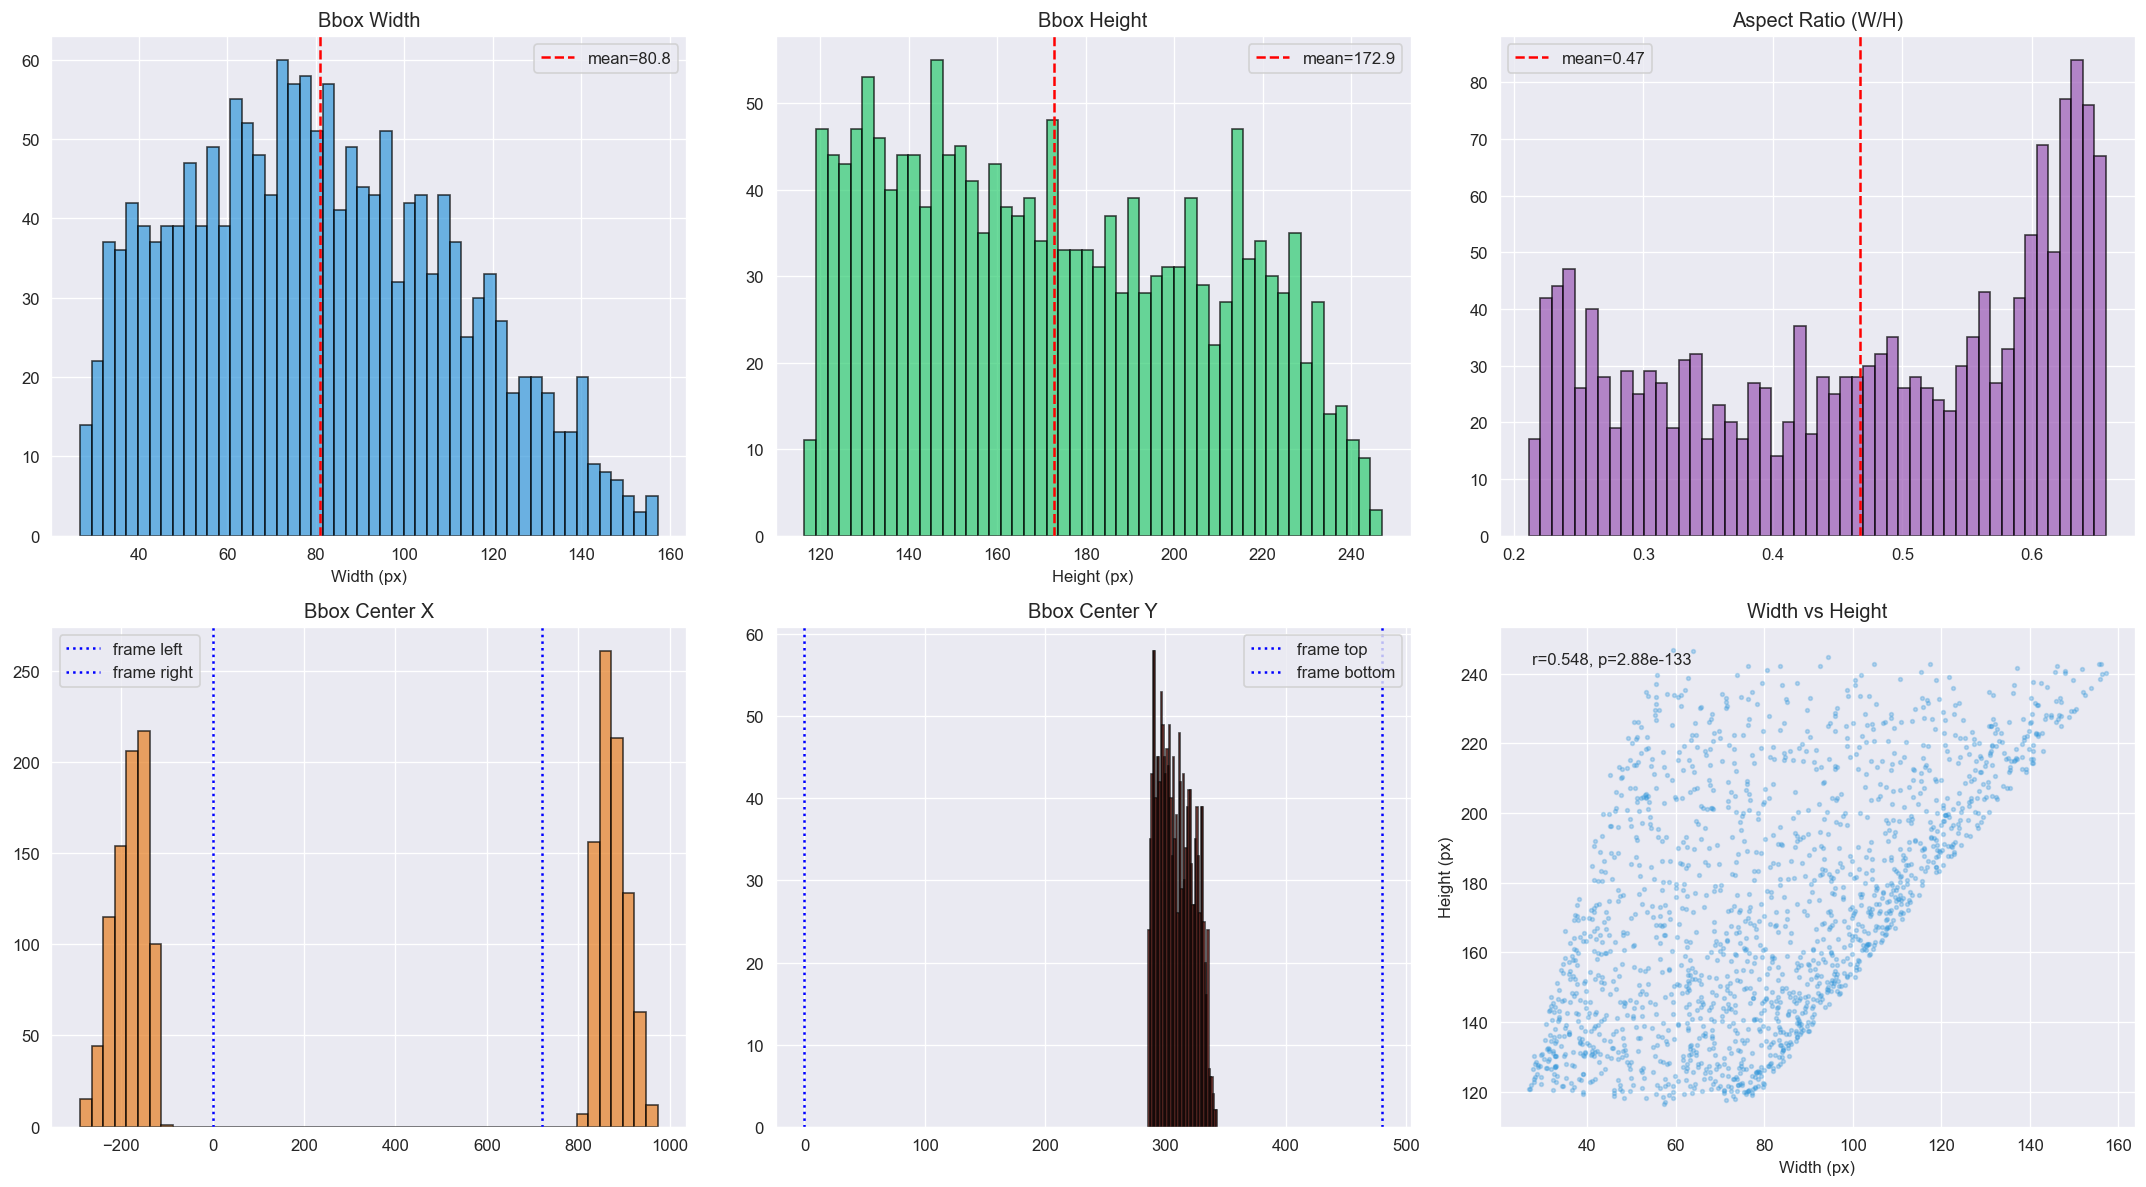

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

widths = [s["bbox_width"] for s in samples]
heights = [s["bbox_height"] for s in samples]
areas = [s["bbox_area"] for s in samples]
centers_x = [s["bbox_center_x"] for s in samples]
centers_y = [s["bbox_center_y"] for s in samples]
aspect_ratios = [s["aspect_ratio"] for s in samples]

axes[0, 0].hist(widths, bins=50, color="#3498db", edgecolor="black", alpha=0.7)
axes[0, 0].set_title("Bbox Width")
axes[0, 0].set_xlabel("Width (px)")
axes[0, 0].axvline(np.mean(widths), color="red", linestyle="--", label=f"mean={np.mean(widths):.1f}")
axes[0, 0].legend()

axes[0, 1].hist(heights, bins=50, color="#2ecc71", edgecolor="black", alpha=0.7)
axes[0, 1].set_title("Bbox Height")
axes[0, 1].set_xlabel("Height (px)")
axes[0, 1].axvline(np.mean(heights), color="red", linestyle="--", label=f"mean={np.mean(heights):.1f}")
axes[0, 1].legend()

axes[0, 2].hist(aspect_ratios, bins=50, color="#9b59b6", edgecolor="black", alpha=0.7)
axes[0, 2].set_title("Aspect Ratio (W/H)")
axes[0, 2].axvline(np.mean(aspect_ratios), color="red", linestyle="--", label=f"mean={np.mean(aspect_ratios):.2f}")
axes[0, 2].legend()

axes[1, 0].hist(centers_x, bins=50, color="#e67e22", edgecolor="black", alpha=0.7)
axes[1, 0].set_title("Bbox Center X")
axes[1, 0].axvline(0, color="blue", linestyle=":", label="frame left")
axes[1, 0].axvline(720, color="blue", linestyle=":", label="frame right")
axes[1, 0].legend()

axes[1, 1].hist(centers_y, bins=50, color="#e74c3c", edgecolor="black", alpha=0.7)
axes[1, 1].set_title("Bbox Center Y")
axes[1, 1].axvline(0, color="blue", linestyle=":", label="frame top")
axes[1, 1].axvline(480, color="blue", linestyle=":", label="frame bottom")
axes[1, 1].legend()

axes[1, 2].scatter(widths, heights, alpha=0.3, s=5, c="#3498db")
axes[1, 2].set_title("Width vs Height")
axes[1, 2].set_xlabel("Width (px)")
axes[1, 2].set_ylabel("Height (px)")
if len(widths) > 2:
    r, p = stats.pearsonr(widths, heights)
    axes[1, 2].text(0.05, 0.95, f"r={r:.3f}, p={p:.2e}", transform=axes[1, 2].transAxes, va="top")

plt.tight_layout()
plt.show()


## 7. Spatial Analysis

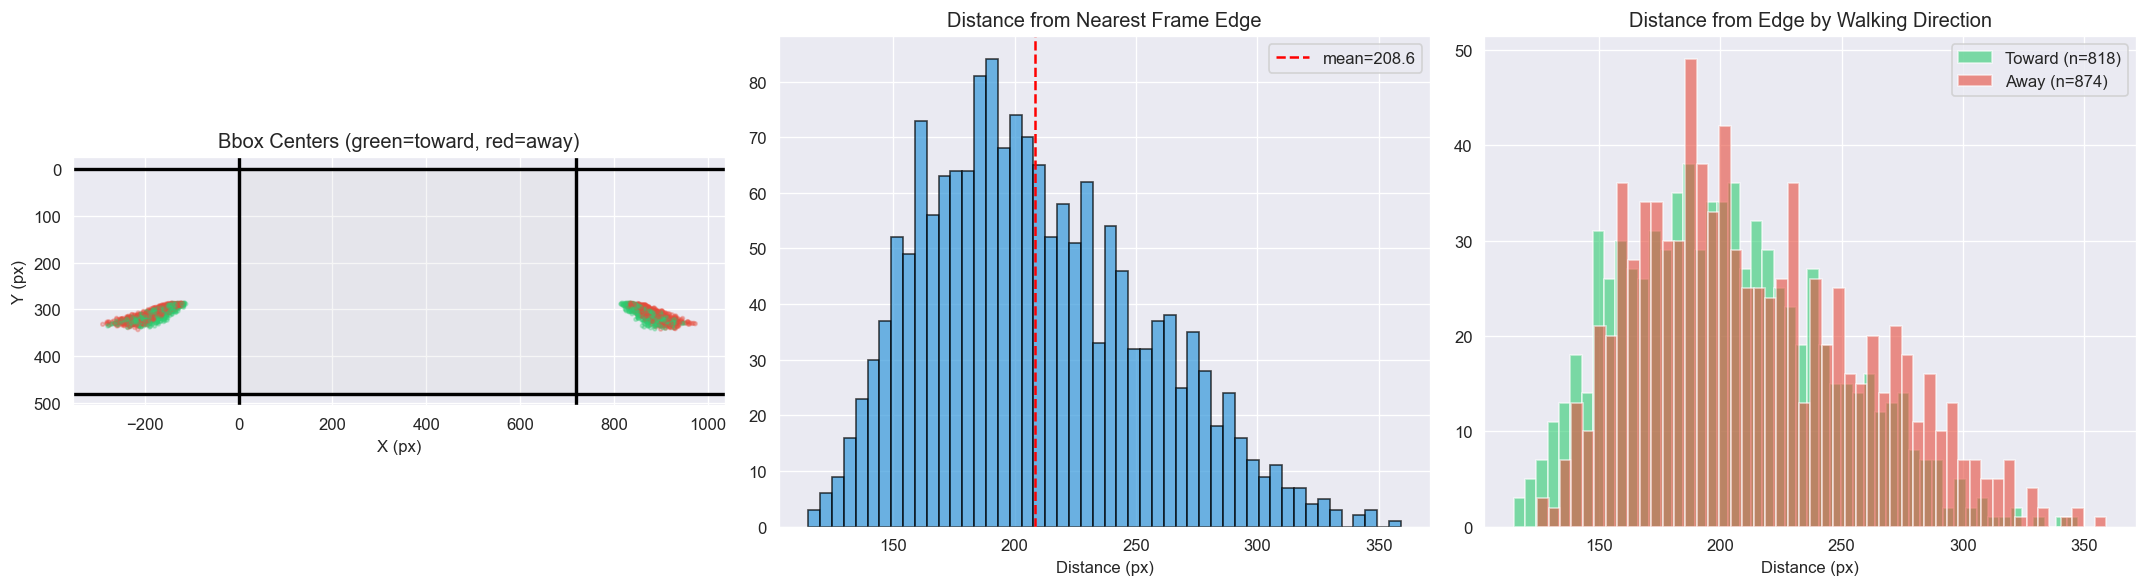

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cx = [s["bbox_center_x"] for s in samples]
cy = [s["bbox_center_y"] for s in samples]
walk = [s["walking_into_frame"] for s in samples]
colors = ["#2ecc71" if w == 1 else "#e74c3c" for w in walk]

axes[0].scatter(cx, cy, c=colors, alpha=0.3, s=5)
axes[0].axvline(0, color="black", linewidth=2)
axes[0].axvline(720, color="black", linewidth=2)
axes[0].axhline(0, color="black", linewidth=2)
axes[0].axhline(480, color="black", linewidth=2)
rect = patches.Rectangle((0, 0), 720, 480, linewidth=2, edgecolor="black", facecolor="lightgray", alpha=0.2)
axes[0].add_patch(rect)
axes[0].set_title("Bbox Centers (green=toward, red=away)")
axes[0].set_xlabel("X (px)")
axes[0].set_ylabel("Y (px)")
axes[0].invert_yaxis()
axes[0].set_aspect("equal")

dists = [s["distance_from_edge"] for s in samples]
axes[1].hist(dists, bins=50, color="#3498db", edgecolor="black", alpha=0.7)
axes[1].set_title("Distance from Nearest Frame Edge")
axes[1].set_xlabel("Distance (px)")
axes[1].axvline(np.mean(dists), color="red", linestyle="--", label=f"mean={np.mean(dists):.1f}")
axes[1].legend()

dist_toward = [s["distance_from_edge"] for s in samples if s["walking_into_frame"] == 1]
dist_away = [s["distance_from_edge"] for s in samples if s["walking_into_frame"] == 0]
axes[2].hist(dist_toward, bins=50, alpha=0.6, color="#2ecc71", label=f"Toward (n={len(dist_toward)})")
axes[2].hist(dist_away, bins=50, alpha=0.6, color="#e74c3c", label=f"Away (n={len(dist_away)})")
axes[2].set_title("Distance from Edge by Walking Direction")
axes[2].set_xlabel("Distance (px)")
axes[2].legend()

plt.tight_layout()
plt.show()


## 8. Bbox Center Heatmap

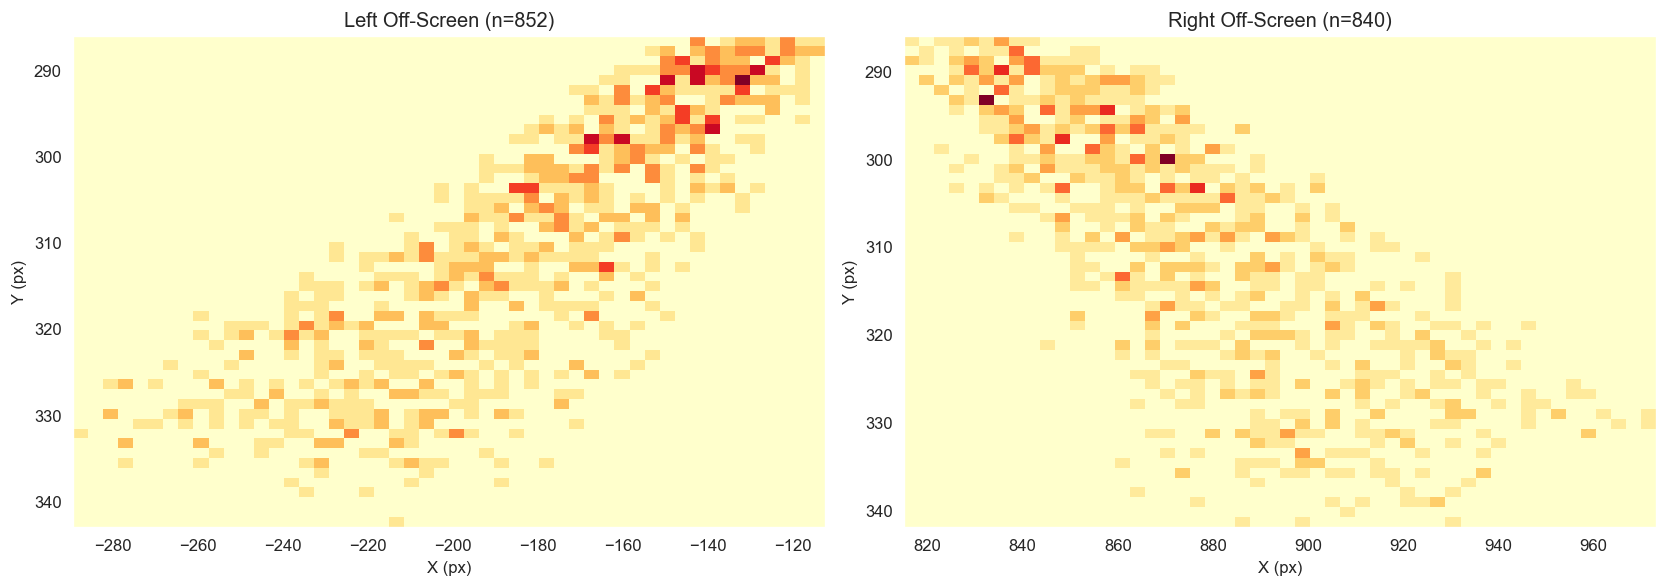

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cx = np.array([s["bbox_center_x"] for s in samples])
cy = np.array([s["bbox_center_y"] for s in samples])

left_mask = cx < 0
if left_mask.sum() > 0:
    axes[0].hist2d(cx[left_mask], cy[left_mask], bins=50, cmap="YlOrRd")
    axes[0].axvline(0, color="white", linewidth=2, linestyle="--")
    axes[0].set_title(f"Left Off-Screen (n={left_mask.sum()})")
    axes[0].set_xlabel("X (px)")
    axes[0].set_ylabel("Y (px)")
    axes[0].invert_yaxis()

right_mask = cx > 720
if right_mask.sum() > 0:
    axes[1].hist2d(cx[right_mask], cy[right_mask], bins=50, cmap="YlOrRd")
    axes[1].axvline(720, color="white", linewidth=2, linestyle="--")
    axes[1].set_title(f"Right Off-Screen (n={right_mask.sum()})")
    axes[1].set_xlabel("X (px)")
    axes[1].set_ylabel("Y (px)")
    axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


## 9. Feature Correlation Matrix

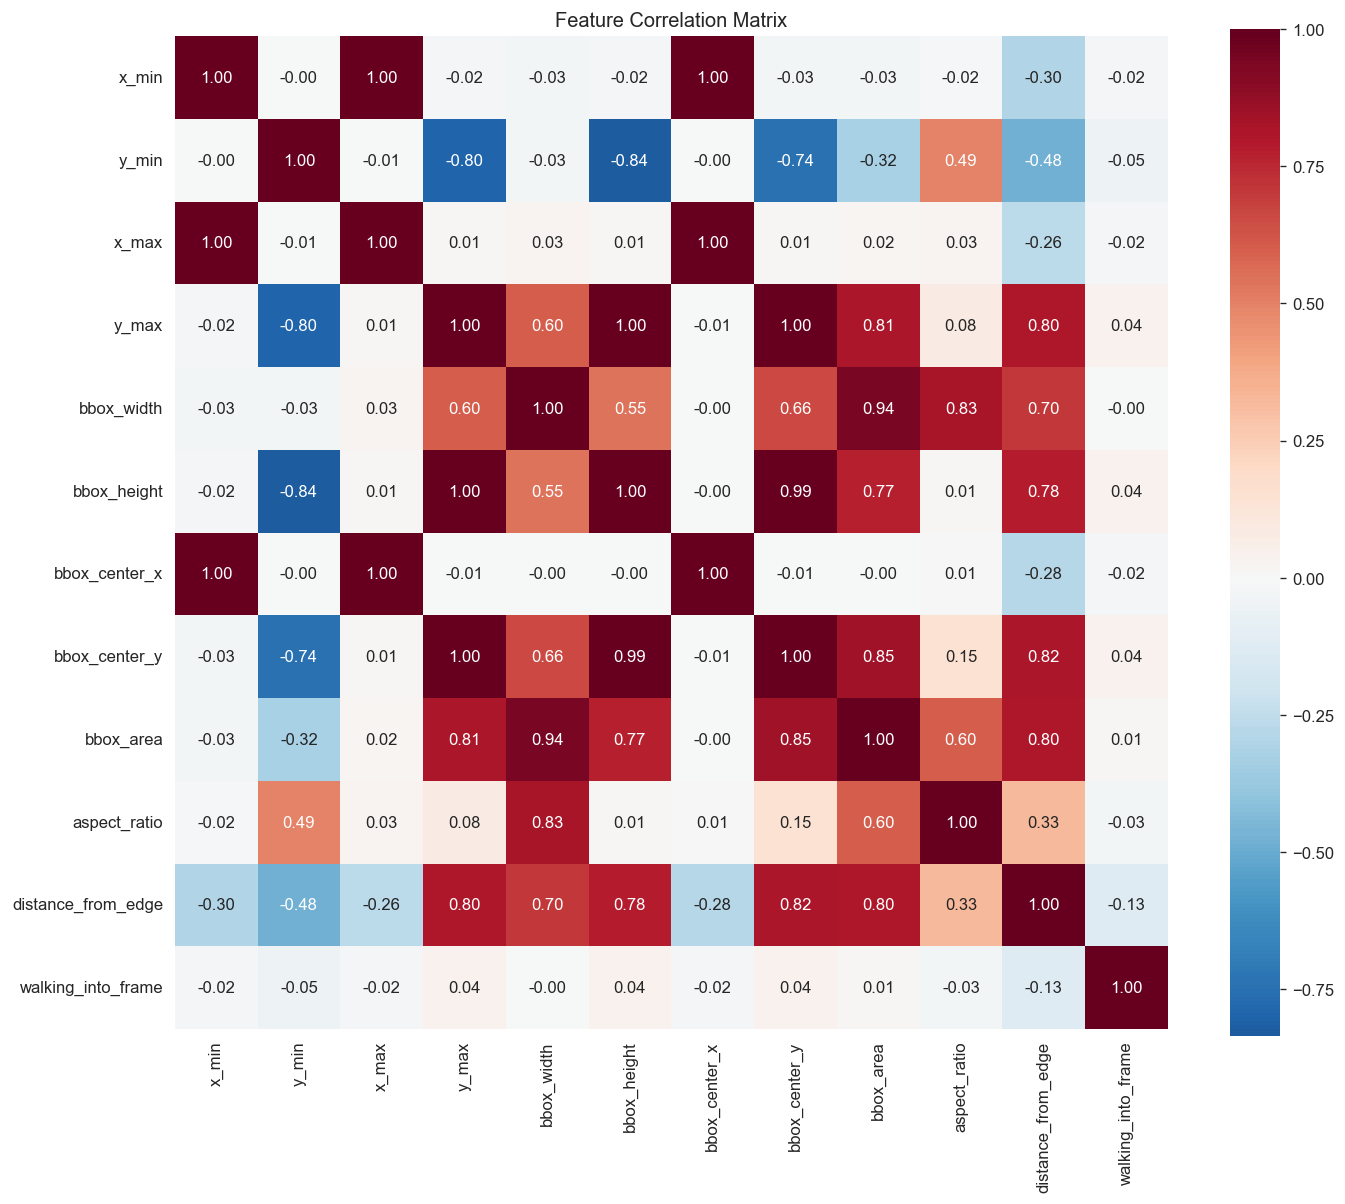

In [10]:
keys = ["x_min", "y_min", "x_max", "y_max", "bbox_width", "bbox_height",
        "bbox_center_x", "bbox_center_y", "bbox_area", "aspect_ratio",
        "distance_from_edge", "walking_into_frame"]
data = {k: [s[k] for s in samples] for k in keys}
arr = np.array([data[k] for k in keys]).T
corr = np.corrcoef(arr, rowvar=False)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, xticklabels=keys, yticklabels=keys, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, ax=ax, square=True)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


## 10. Sample Images with Off-Screen Bounding Boxes

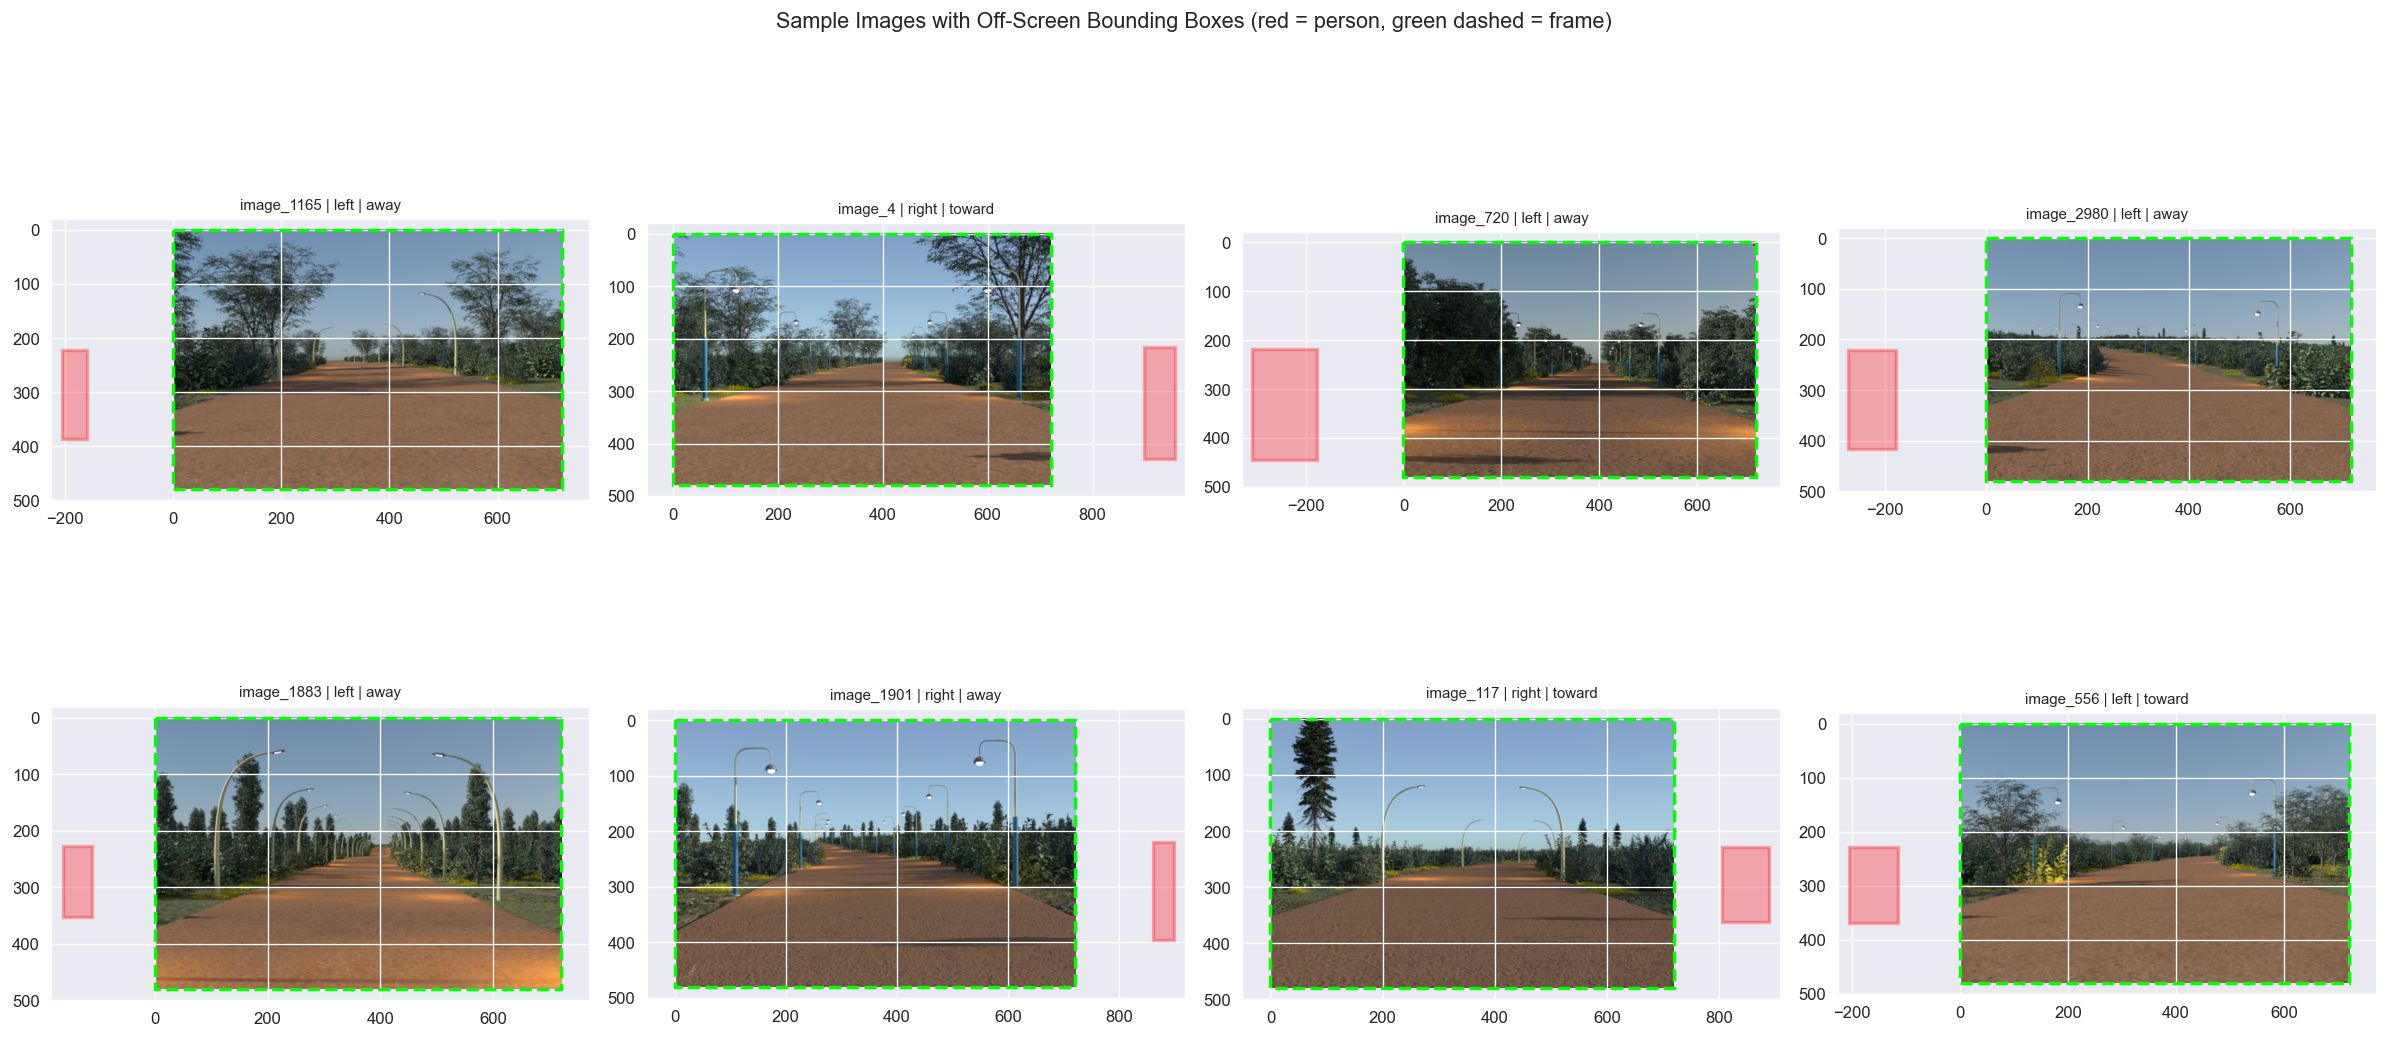

In [11]:
rng = np.random.default_rng(42)
n = 8
indices = rng.choice(len(samples), size=min(n, len(samples)), replace=False)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, idx in enumerate(indices):
    s = samples[idx]
    img = Image.open(s["img_path"]).convert("RGB")
    axes[i].imshow(img, extent=[0, 720, 480, 0])

    rect = patches.Rectangle(
        (s["x_min"], s["y_min"]),
        s["bbox_width"], s["bbox_height"],
        linewidth=2, edgecolor="red", facecolor="red", alpha=0.3
    )
    axes[i].add_patch(rect)

    frame = patches.Rectangle((0, 0), 720, 480, linewidth=2,
                               edgecolor="lime", facecolor="none", linestyle="--")
    axes[i].add_patch(frame)

    direction = "toward" if s["walking_into_frame"] == 1 else "away"
    axes[i].set_title(f"{s['file_name']} | {s['person_side']} | {direction}", fontsize=9)
    axes[i].set_xlim(min(s["x_min"] - 20, -50), max(s["x_max"] + 20, 770))
    axes[i].set_ylim(500, -20)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Sample Images with Off-Screen Bounding Boxes (red = person, green dashed = frame)", fontsize=13)
plt.tight_layout()
plt.show()


## 11. Pixel-Level Analysis

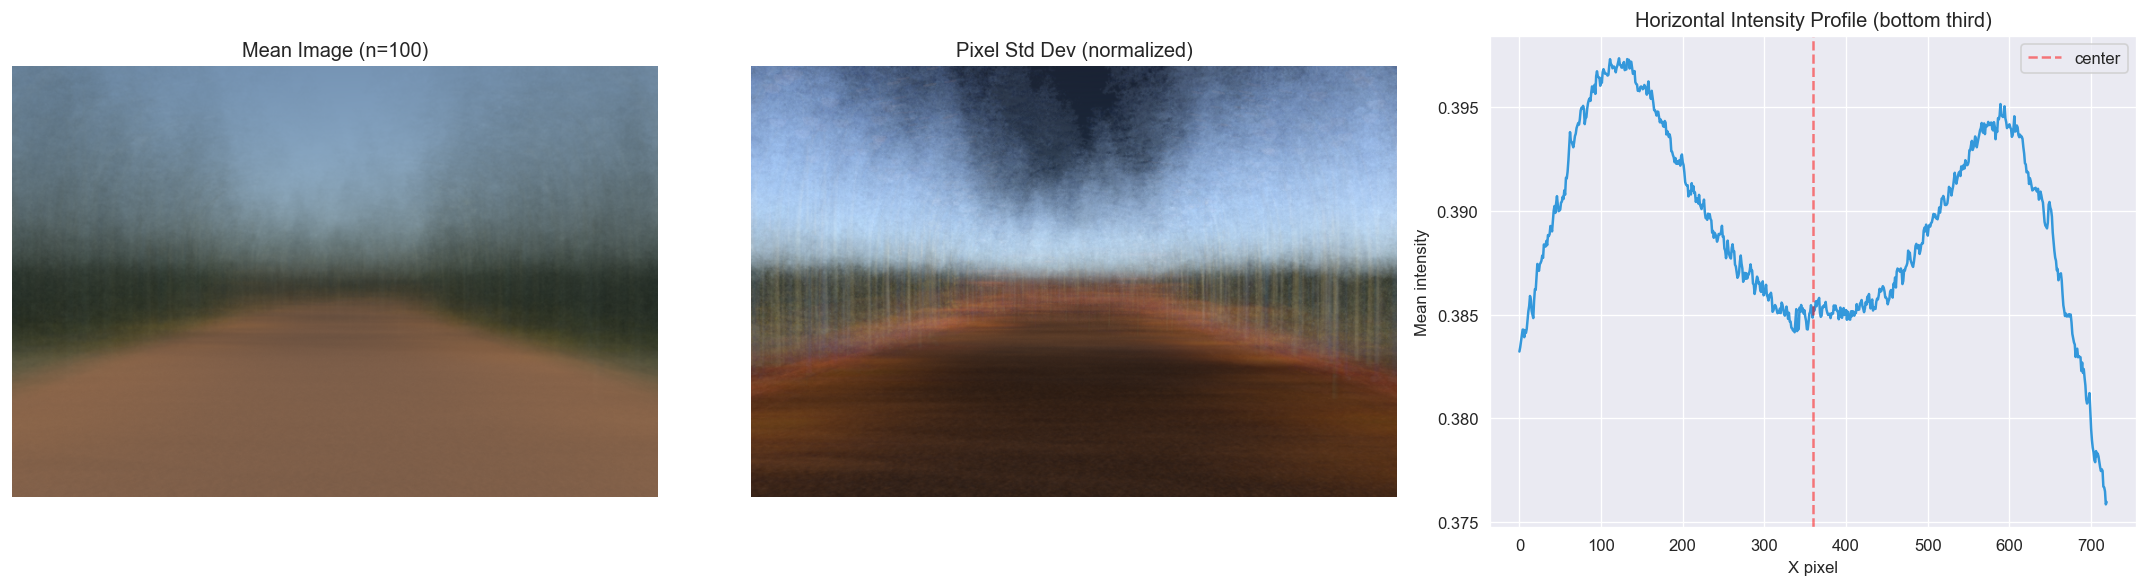

In [12]:
rng = np.random.default_rng(42)
n_sample = min(100, len(samples))
indices = rng.choice(len(samples), size=n_sample, replace=False)

mean_img = np.zeros((480, 720, 3), dtype=np.float64)
for idx in indices:
    img = open_img(samples[idx]["img_path"], size=(720, 480))
    mean_img += img
mean_img /= n_sample

var_img = np.zeros((480, 720, 3), dtype=np.float64)
for idx in indices:
    img = open_img(samples[idx]["img_path"], size=(720, 480))
    var_img += (img - mean_img) ** 2
var_img /= n_sample
std_img = np.sqrt(var_img)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(mean_img)
axes[0].set_title(f"Mean Image (n={n_sample})")
axes[0].axis("off")

axes[1].imshow(std_img / std_img.max())
axes[1].set_title("Pixel Std Dev (normalized)")
axes[1].axis("off")

bottom_third = mean_img[320:, :, :]
horizontal_profile = bottom_third.mean(axis=(0, 2))
axes[2].plot(horizontal_profile, color="#3498db")
axes[2].set_title("Horizontal Intensity Profile (bottom third)")
axes[2].set_xlabel("X pixel")
axes[2].set_ylabel("Mean intensity")
axes[2].axvline(360, color="red", linestyle="--", alpha=0.5, label="center")
axes[2].legend()

plt.tight_layout()
plt.show()


## 12. Regression Target Analysis

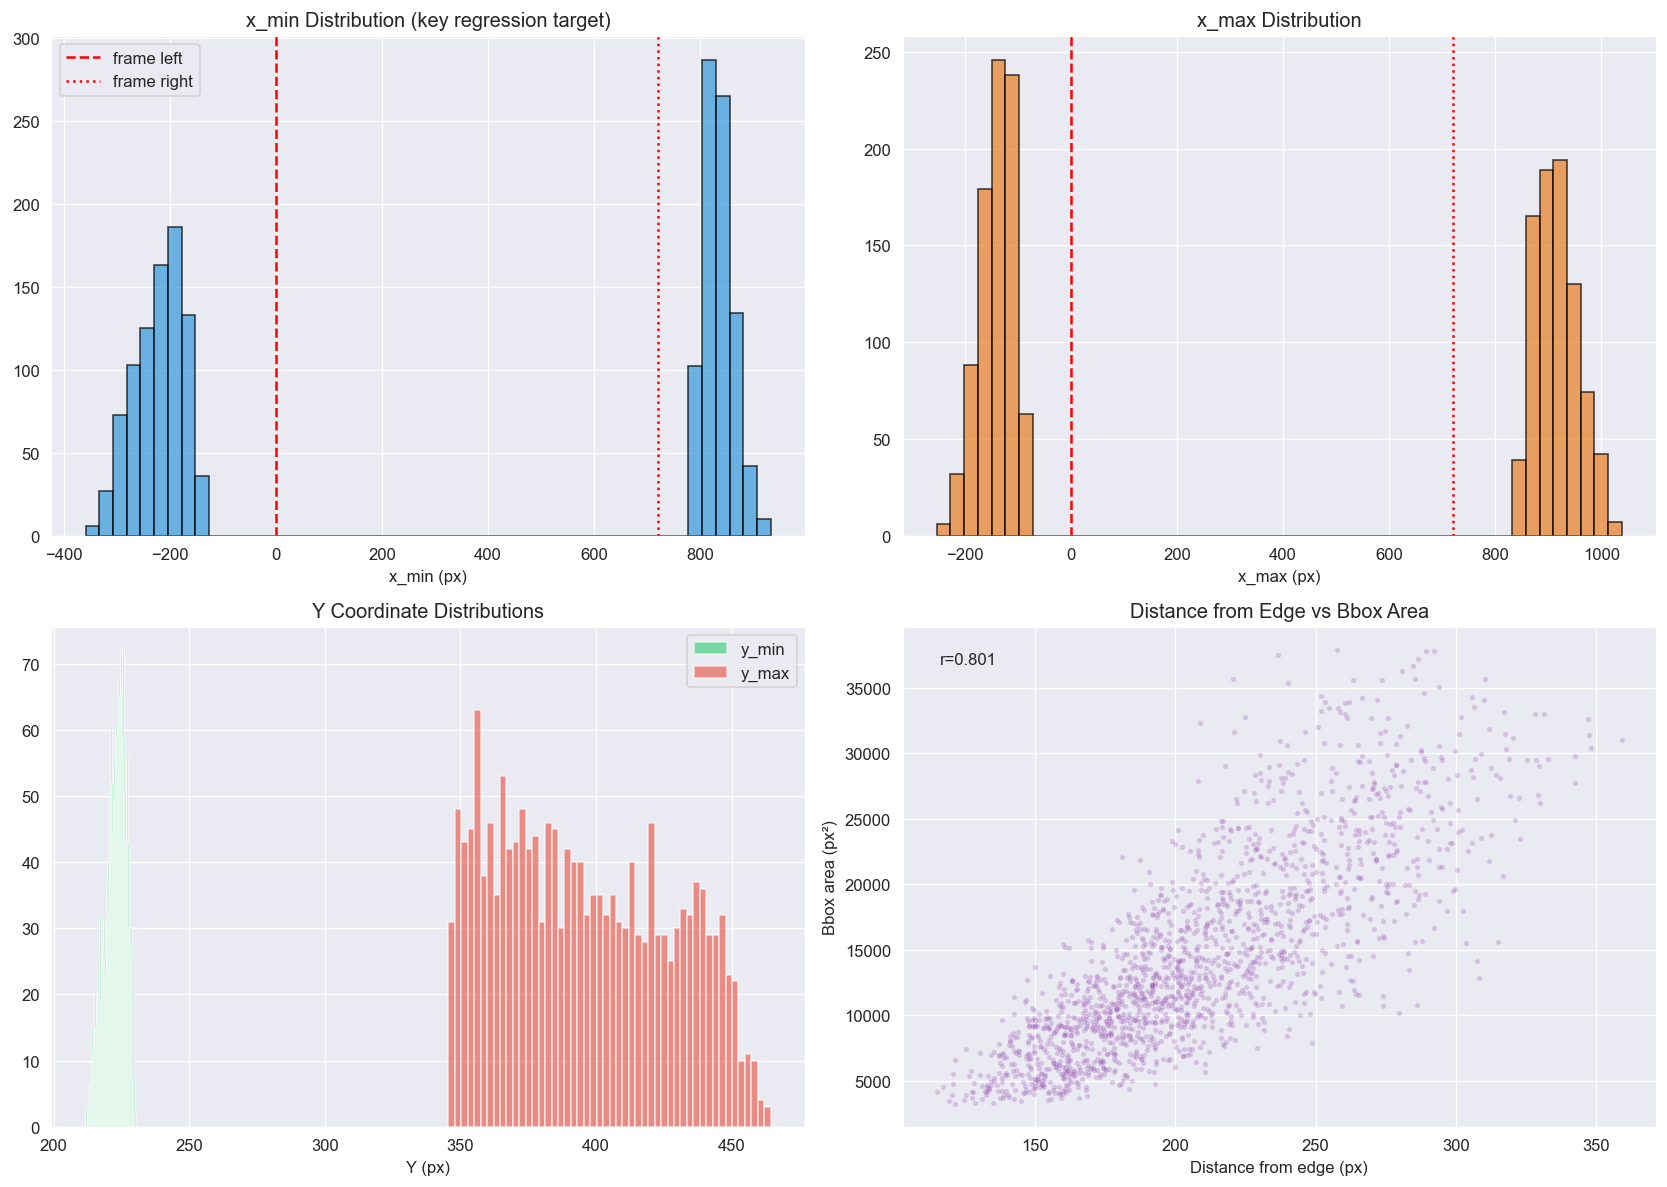

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

x_mins = [s["x_min"] for s in samples]
axes[0, 0].hist(x_mins, bins=50, color="#3498db", edgecolor="black", alpha=0.7)
axes[0, 0].set_title("x_min Distribution (key regression target)")
axes[0, 0].set_xlabel("x_min (px)")
axes[0, 0].axvline(0, color="red", linestyle="--", label="frame left")
axes[0, 0].axvline(720, color="red", linestyle=":", label="frame right")
axes[0, 0].legend()

x_maxs = [s["x_max"] for s in samples]
axes[0, 1].hist(x_maxs, bins=50, color="#e67e22", edgecolor="black", alpha=0.7)
axes[0, 1].set_title("x_max Distribution")
axes[0, 1].set_xlabel("x_max (px)")
axes[0, 1].axvline(0, color="red", linestyle="--")
axes[0, 1].axvline(720, color="red", linestyle=":")

y_mins = [s["y_min"] for s in samples]
y_maxs = [s["y_max"] for s in samples]
axes[1, 0].hist(y_mins, bins=50, alpha=0.6, color="#2ecc71", label="y_min")
axes[1, 0].hist(y_maxs, bins=50, alpha=0.6, color="#e74c3c", label="y_max")
axes[1, 0].set_title("Y Coordinate Distributions")
axes[1, 0].set_xlabel("Y (px)")
axes[1, 0].legend()

dists = [s["distance_from_edge"] for s in samples]
areas = [s["bbox_area"] for s in samples]
axes[1, 1].scatter(dists, areas, alpha=0.2, s=5, c="#9b59b6")
axes[1, 1].set_title("Distance from Edge vs Bbox Area")
axes[1, 1].set_xlabel("Distance from edge (px)")
axes[1, 1].set_ylabel("Bbox area (px\u00b2)")
if len(dists) > 2:
    r, p = stats.pearsonr(dists, areas)
    axes[1, 1].text(0.05, 0.95, f"r={r:.3f}", transform=axes[1, 1].transAxes, va="top")

plt.tight_layout()
plt.show()


## 13. Shadow-Specific Analysis

Mean images split by person side (left vs right) and walking direction.


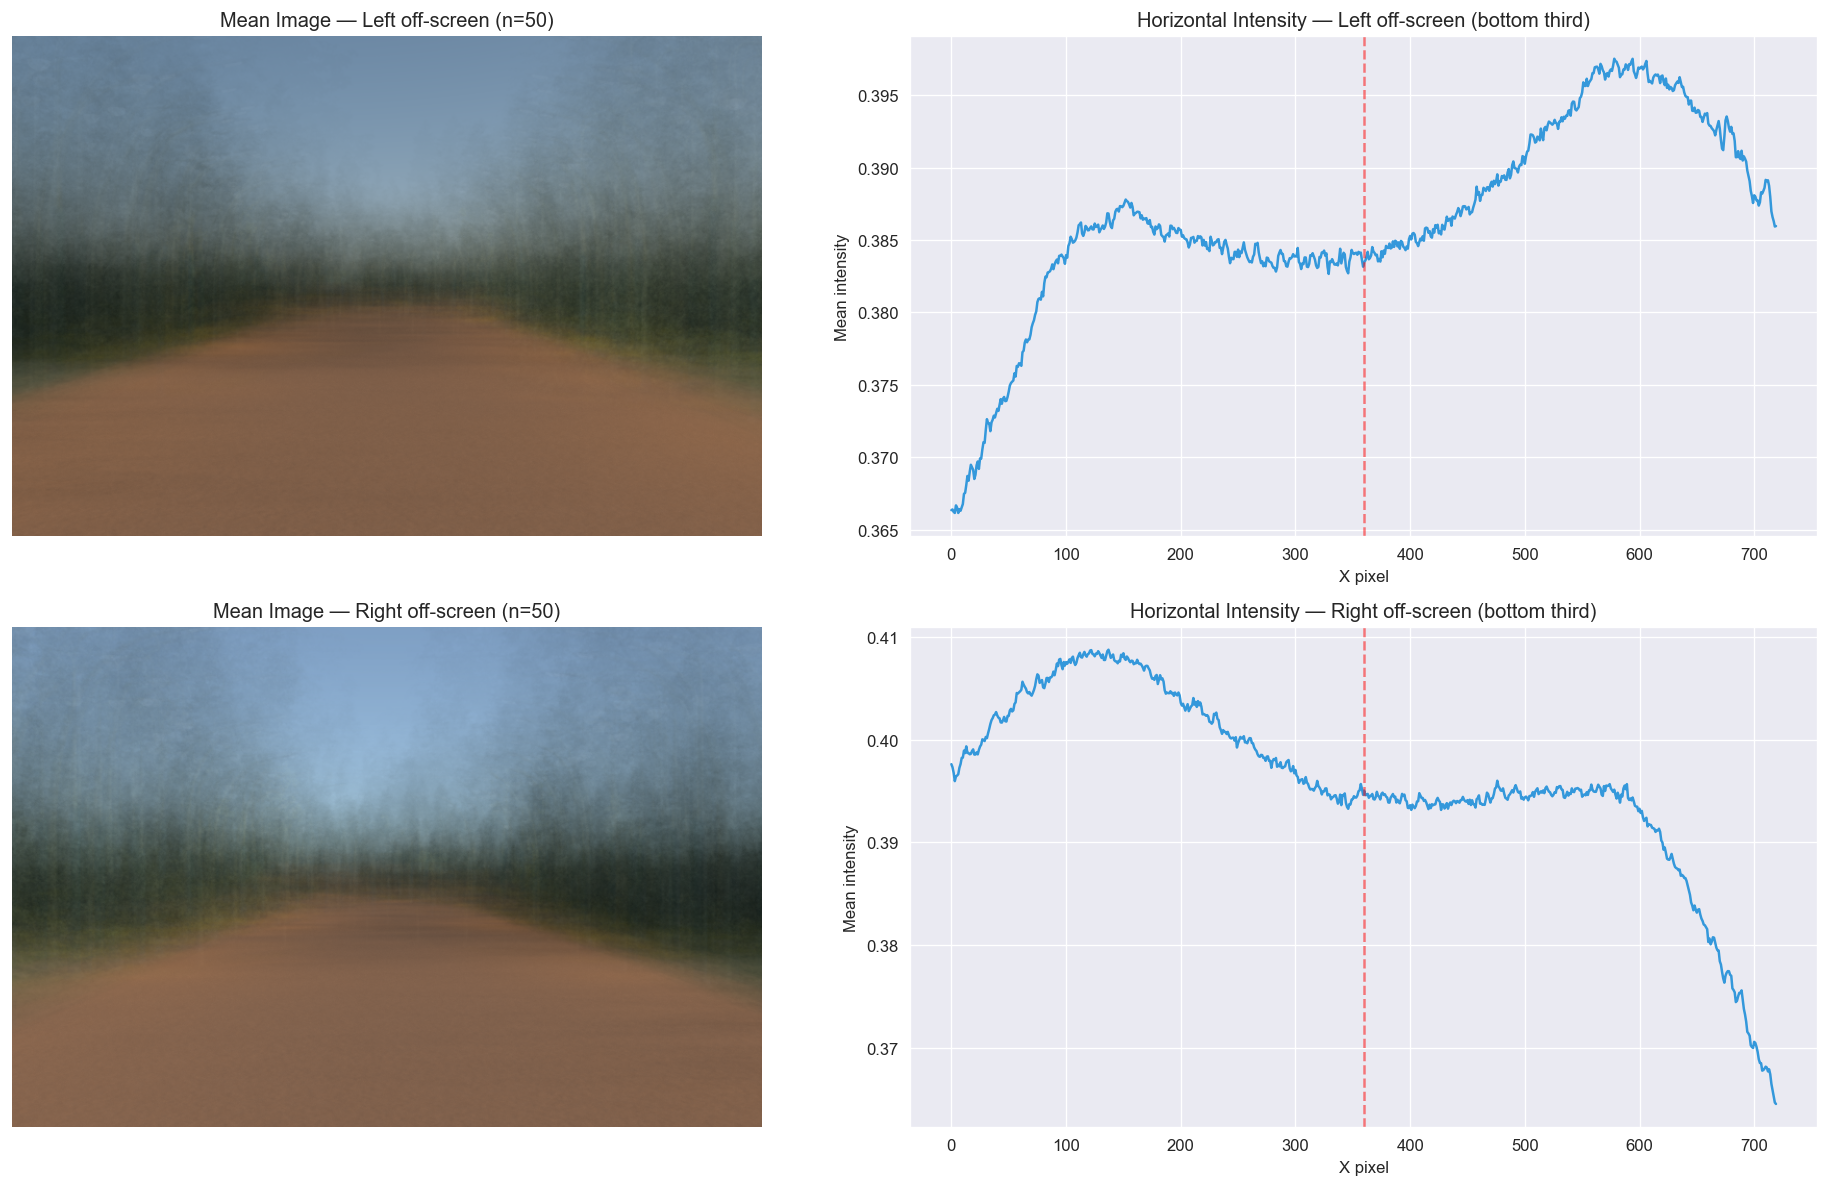

In [14]:
left_samples = [s for s in samples if s["person_side"] == "left"]
right_samples = [s for s in samples if s["person_side"] == "right"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for group, label, row in [(left_samples, "Left off-screen", 0), (right_samples, "Right off-screen", 1)]:
    if len(group) == 0:
        continue
    rng = np.random.default_rng(42)
    n_s = min(50, len(group))
    idxs = rng.choice(len(group), size=n_s, replace=False)

    grp_mean = np.zeros((480, 720, 3), dtype=np.float64)
    for idx in idxs:
        grp_mean += open_img(group[idx]["img_path"], size=(720, 480))
    grp_mean /= n_s

    axes[row, 0].imshow(grp_mean)
    axes[row, 0].set_title(f"Mean Image — {label} (n={n_s})")
    axes[row, 0].axis("off")

    bottom = grp_mean[320:, :, :].mean(axis=(0, 2))
    axes[row, 1].plot(bottom, color="#3498db")
    axes[row, 1].set_title(f"Horizontal Intensity — {label} (bottom third)")
    axes[row, 1].set_xlabel("X pixel")
    axes[row, 1].set_ylabel("Mean intensity")
    axes[row, 1].axvline(360, color="red", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


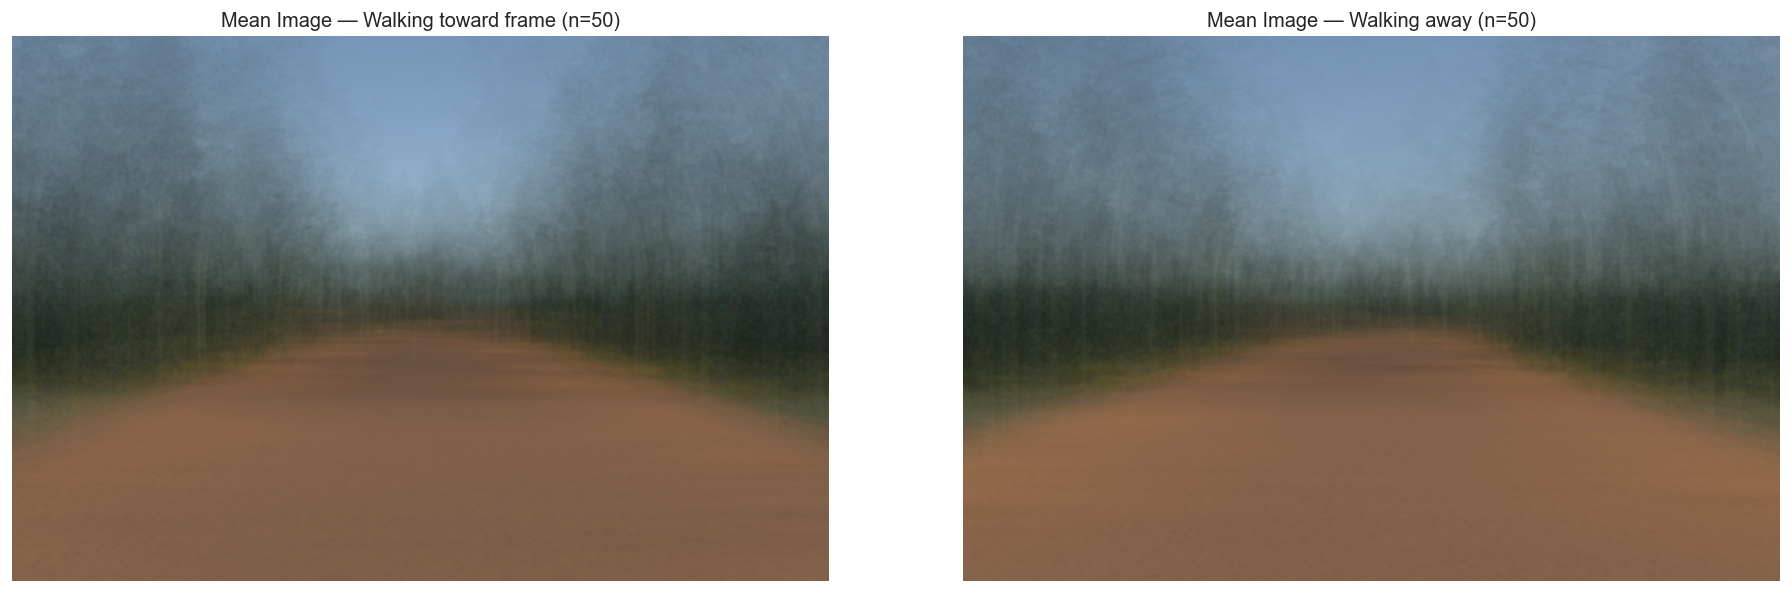

In [15]:
toward_samples = [s for s in samples if s["walking_into_frame"] == 1]
away_samples = [s for s in samples if s["walking_into_frame"] == 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for group, label, col in [(toward_samples, "Walking toward frame", 0), (away_samples, "Walking away", 1)]:
    if len(group) == 0:
        continue
    rng = np.random.default_rng(42)
    n_s = min(50, len(group))
    idxs = rng.choice(len(group), size=n_s, replace=False)

    grp_mean = np.zeros((480, 720, 3), dtype=np.float64)
    for idx in idxs:
        grp_mean += open_img(group[idx]["img_path"], size=(720, 480))
    grp_mean /= n_s

    axes[col].imshow(grp_mean)
    axes[col].set_title(f"Mean Image — {label} (n={n_s})")
    axes[col].axis("off")

plt.tight_layout()
plt.show()
